In [3]:
import torch
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
embeddings1=torch.load('embeddings_hidden_10_epochs.pth')

In [4]:
embeddings1=embeddings1.T

In [5]:
import pandas as pd
df=pd.read_csv('wordsim353.csv')

In [20]:
data=torch.load('skipgram_data_66M.pth')
vocab=data['vocab']
word2index={word:index for word,index in vocab.items()}

In [24]:
from torch.nn.functional import cosine_similarity
similarity=[]
for i in range(len(df)):
    if df['Word_1'][i] in vocab.keys() and df['Word_2'][i] in vocab.keys():
        index_a=vocab[df['Word_1'][i]]
        index_b=vocab[df['Word_2'][i]]
        a=embeddings1[index_a]
        b=embeddings1[index_b]
        similarity.append(cosine_similarity(a.unsqueeze(0),b.unsqueeze(0)).item()*10)
    else:
        df=df.drop([i])
        #similarity.append('NaN')

In [25]:
len(df)

333

In [26]:
df['model_score']=similarity
import scipy
print(scipy.stats.spearmanr(df['score'],df['model_score']))

SignificanceResult(statistic=np.float64(0.6173518861555143), pvalue=np.float64(2.2884976892717402e-36))


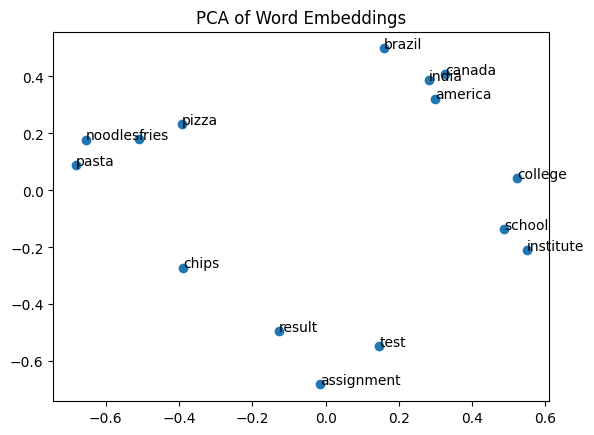

In [33]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Words to visualize
words = [
    'noodles','pizza','fries','pasta','chips',
    'india','canada','america','brazil',
    'test','assignment','result','school','college','institute'
]

# Get embedding matrix


# Normalize (recommended)
embeddings1 = F.normalize(embeddings1, dim=1)

# Collect vectors
vectors = []
valid_words = []

for word in words:
    if word in word2index:
        idx = word2index[word]
        vectors.append(embeddings1[idx].cpu().numpy())
        valid_words.append(word)
    else:
        print(f"{word} not in vocabulary")

vectors = torch.tensor(vectors).numpy()

# Apply PCA
pca = PCA(n_components=2)
reduced = pca.fit_transform(vectors)

# Plot
plt.figure()
plt.scatter(reduced[:, 0], reduced[:, 1])

for i, word in enumerate(valid_words):
    plt.annotate(word, (reduced[i, 0], reduced[i, 1]))

plt.title("PCA of Word Embeddings")
plt.show()


In [34]:
df1=pd.read_csv('Analogy.csv')
df1.head()

,word1,word2,word3,word4
0,Athens,Greece,Baghdad,Iraq
1,Athens,Greece,Bangkok,Thailand
2,Athens,Greece,Beijing,China
3,Athens,Greece,Berlin,Germany
4,Athens,Greece,Bern,Switzerland


In [49]:
index2word={index:word for word,index in vocab.items()}

In [71]:
#index2word={index:word for word,index in vocab.items()}
from tqdm import tqdm
import torch.nn.functional as F
correct=0
total=0
for i in tqdm(range(200)):
    a=df1['word1'][i].lower()
    b=df1['word2'][i].lower()
    c=df1['word3'][i].lower()
    if a in vocab and b in vocab and c in vocab:
        target_vec=embeddings1[vocab[b]]+embeddings1[vocab[c]]-embeddings1[vocab[a]]
        target_vec=F.normalize(target_vec,dim=0)
        similarities=torch.matmul(embeddings1,target_vec)
        similarities[vocab[a]]=1e-9
        similarities[vocab[b]]=1e-9
        similarities[vocab[c]]=1e-9
        pred_index=torch.argmax(similarities).item()
        pred_word=index2word[pred_index]
        print(pred_word)
        #print(pred_word)
        if (pred_word==df1['word4'][i].lower()):
            correct+=1
        total+=1
    else:
        print(i)

100%|██████████| 200/200 [00:00<00:00, 2717.30it/s]

afghanistan
indonesia
laos
germany
switzerland
egypt
australia
laos
cuba
finland
pakistan
afghanistan
france
france
romania
denmark
canada
france
egypt
sweden
turkmenistan
japan
indonesia
taiwan
germany
switzerland
egypt
australia
cambodia
cuba
finland
pakistan
afghanistan
britain
francoist
russia
finland
canada
france
greece
finland
iran
japan
greece
tibet
poland
bamberger
egypt
tibet
tibet
paraguay
serbia
tibet
persia
strassburg
spain
romania
norway
quebec
france
greece
norway
tibet
japan
greece
persia
germany
salzburg
egypt
queensland
japan
peru
finland
pakistan
afghanistan
england
spain
russia
denmark
quebec
france
persia
norway
japan
japan
greece
persia
singapore
switzerland
libya
australia
spain
spain
finland
pakistan
kandahar
england
spain
russia
finland
canada
france
spain
norway
iran
nagano
greece
iraq
singapore
china
algeria
australia
cambodia
cuba
finland
pakistan
afghanistan
paris
spain
russia
denmark
canada
france
greece
norway
iran
japan
greece
iraq
thailand
china
germany

In [72]:
print(correct/total)

0.475


In [53]:
vocab['germany']

1044